c:\Users\Lenovo\OneDrive\Documents\Jupyter\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Lenovo\OneDrive\Documents\Jupyter\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Loaded 14 tennis observations from c:\Users\Lenovo\OneDrive\Desktop\data-science-playground\data-science-playground\data-science-playground\Machine-Learning-Lab\data\Tennis.csv


,Outlook,Temperature,Humidity,Wind,PlayTennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


Play Tennis Prediction: Yes


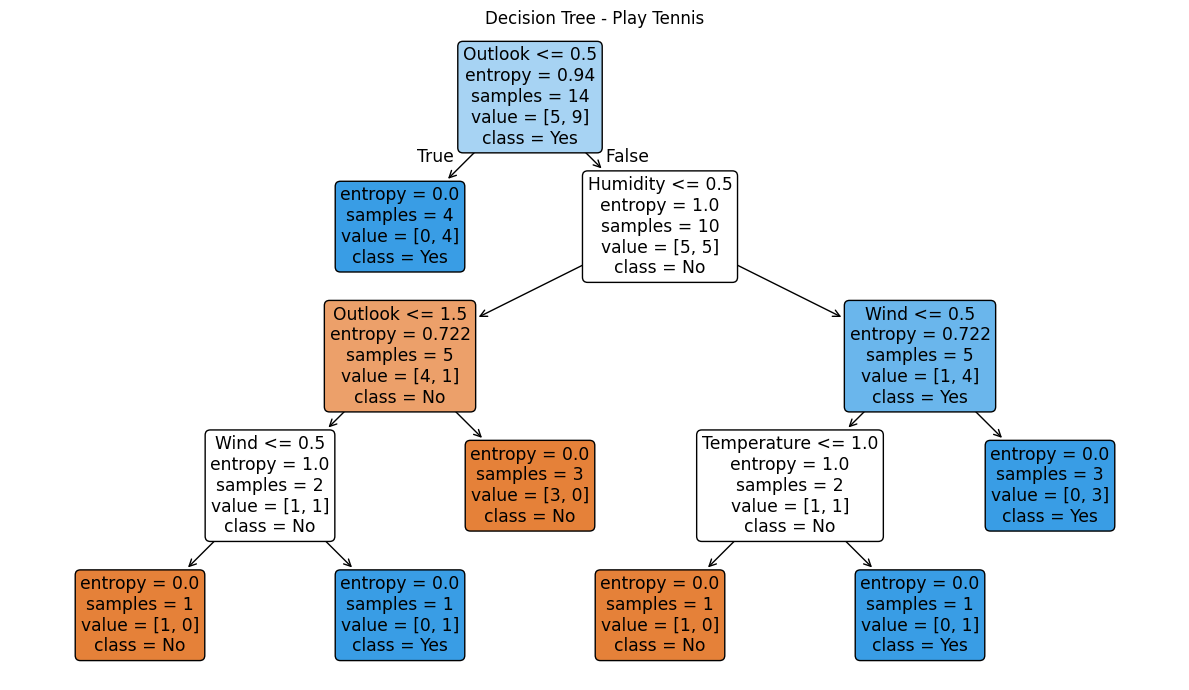

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree


DATA_FILE = "Tennis.csv"
REQUIRED_COLUMNS = {"Outlook", "Temperature", "Humidity", "Wind", "PlayTennis"}


def find_data_file(filename: str) -> Path:
    """Find a lab data file from the repository root or this notebook's folder."""
    current_dir = Path.cwd()
    candidates = (
        current_dir / "Machine-Learning-Lab" / "data" / filename,
        current_dir / "data" / filename,
        current_dir.parent / "data" / filename,
    )

    for candidate in candidates:
        if candidate.is_file():
            return candidate

    searched_paths = "\n".join(str(path) for path in candidates)
    raise FileNotFoundError(f"Could not find {filename}. Searched:\n{searched_paths}")


csv_path = find_data_file(DATA_FILE)
data = pd.read_csv(csv_path)

missing_columns = REQUIRED_COLUMNS.difference(data.columns)
if missing_columns:
    raise ValueError(f"Tennis.csv is missing columns: {sorted(missing_columns)}")

print(f"Loaded {len(data)} tennis observations from {csv_path}")
display(data.head())

feature_columns = ["Outlook", "Temperature", "Humidity", "Wind"]
target_column = "PlayTennis"

# Keep an encoder for each column so new observations use the correct mapping.
encoders = {}
encoded_data = data.copy()
for column in feature_columns + [target_column]:
    encoder = LabelEncoder()
    encoded_data[column] = encoder.fit_transform(data[column])
    encoders[column] = encoder

X = encoded_data[feature_columns]
y = encoded_data[target_column]

model = DecisionTreeClassifier(criterion="entropy", random_state=42)
model.fit(X, y)

new_day = pd.DataFrame(
    [{
        "Outlook": "Overcast",
        "Temperature": "Mild",
        "Humidity": "High",
        "Wind": "Strong",
    }]
)
encoded_new_day = new_day.copy()
for column in feature_columns:
    encoded_new_day[column] = encoders[column].transform(new_day[column])

prediction = model.predict(encoded_new_day)[0]
predicted_label = encoders[target_column].inverse_transform([prediction])[0]
print(f"Play Tennis Prediction: {predicted_label}")

plt.figure(figsize=(12, 7))
plot_tree(
    model,
    feature_names=feature_columns,
    class_names=encoders[target_column].classes_,
    filled=True,
    rounded=True,
)
plt.title("Decision Tree - Play Tennis")
plt.tight_layout()
plt.show()
